# RetailPulse: Supply Chain & Retail Analytics
## End-to-End Data Analysis Project

**Author:** Samiya Imran  
**Domain:** Retail / E-commerce / Supply Chain  
**Tools:** Python · Pandas · NumPy · Matplotlib · SQL Server · Tableau  

---

### Business Problem

GlobalMart, a multi-region retail operation, is experiencing **simultaneous stockout and overstock issues** across its warehouses while its supply chain partner (DataCo) reports a **54.8% late delivery rate**. The company needs a unified data view to diagnose root causes, track KPIs, and make data-driven decisions.

### Datasets Used

| Dataset | Source | Rows | What it covers |
|---|---|---|---|
| ML-Dataset | Kaggle | 400 | Hardware orders across 9 global warehouses |
| DataCo Supply Chain | Kaggle | 180,519 | Global retail orders with shipping & delivery data |
| Olist E-Commerce | Kaggle | 99,441+ | Brazilian marketplace — orders, reviews, payments |

### Project Structure

1. Data Preparation (loading + cleaning + integration)  
2. Exploratory Data Analysis (distributions + patterns)  
3. KPI Analysis (business metrics + performance)  
4. Business Insights & Recommendations  
5. SQL Showcase  


# Section 1 — Data Preparation
* Loading raw files, fixing data quality issues, and integrating three datasets into a unified analytical structure.

In [1]:
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import re
print('Libraries loaded succesfully')

Libraries loaded succesfully


In [2]:
# Display setiings
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', 30)

# Plot Style Settings
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False
})

In [3]:
# Loading csv files
ml = pd.read_csv('RetailPulseDataset/ML-Dataset.csv')
# Used latin1 encoding due to UTF-8 decoding error in dataset
dataco   = pd.read_csv('RetailPulseDataset/DataCoSupplyChainDataset.csv', encoding='latin1')
ol_ord   = pd.read_csv('RetailPulseDataset/olist_orders_dataset.csv')
ol_items = pd.read_csv('RetailPulseDataset/olist_order_items_dataset.csv')
ol_cust  = pd.read_csv('RetailPulseDataset/olist_customers_dataset.csv')
ol_prod  = pd.read_csv('RetailPulseDataset/olist_products_dataset.csv')
ol_sell  = pd.read_csv('RetailPulseDataset/olist_sellers_dataset.csv')
ol_rev   = pd.read_csv('RetailPulseDataset/olist_order_reviews_dataset.csv')
ol_pay   = pd.read_csv('RetailPulseDataset/olist_order_payments_dataset.csv')
ol_geo   = pd.read_csv('RetailPulseDataset/olist_geolocation_dataset.csv')
cat_tr   = pd.read_csv('RetailPulseDataset/product_category_name_translation.csv')

# Created a summary DataFrame to compare row and column counts across all datasets
summary = pd.DataFrame({
    'File' : ['ML-Dataset','DataCo','Olist Orders','Olist Items','Olist Customers',
            'Olist Products','Olist Sellers','Olist Reviews','Olist Payments','Geolocation','Category Translation'],
    'Columns' : [ml.shape[1], dataco.shape[1], ol_ord.shape[1], ol_items.shape[1], ol_cust.shape[1],
                 ol_prod.shape[1], ol_sell.shape[1], ol_rev.shape[1],ol_pay.shape[1],ol_geo.shape[1],cat_tr.shape[1]],
    'Rows' : [ml.shape[0], dataco.shape[0], ol_ord.shape[0], ol_items.shape[0], ol_cust.shape[0],# len(df) can also be used for the same purpose but used shape-
                 ol_prod.shape[0], ol_sell.shape[0], ol_rev.shape[0],ol_pay.shape[0],ol_geo.shape[0],cat_tr.shape[0]],# to follow pandas-native syntax for row count 
})
print('All files loaded successfully\n')
summary 

All files loaded successfully



,File,Columns,Rows
0,ML-Dataset,28,400
1,DataCo,53,180519
2,Olist Orders,8,99441
3,Olist Items,7,112650
4,Olist Customers,5,99441
5,Olist Products,9,32951
6,Olist Sellers,4,3095
7,Olist Reviews,7,99224
8,Olist Payments,5,103886
9,Geolocation,5,1000163


# Data Quality Isuues Found & Fixed

Before analysis, the following issues were identified and resolved:

In [4]:
# ml dataset cleaning 
# Issue 1: RegionName has double spaces
ml['RegionName'] = ml['RegionName'].str.strip().str.replace(r'\s+',' ', regex=True)

# Issue 2: WarehouseName has typo 'New Jersy'
ml['WarehouseName'] = ml['WarehouseName'].str.strip().str.replace('New Jersy', 'New Jersey')

# Issue 3: Dates stored as strings '17-Nov-16' not datetime
ml['OrderDate'] = pd.to_datetime(ml['OrderDate'],format='%d-%b-%y',errors='coerce')
ml['EmployeeHireDate'] = pd.to_datetime(ml['EmployeeHireDate'],format='%d-%b-%y',errors='coerce')

# Issue 4: No revenue or margin columns —  so engineered them
ml['Revenue'] = (ml['PerUnitPrice'] * ml['OrderItemQuantity']).round(2)
ml['Profit_margin_pct'] = (ml['Profit'] / ml['Revenue'] * 100).round(2)

# Issue 5: Zero quantity rows are anomalies
ml['qty_anomaly_flag'] = (ml['TotalItemQuantity'] == 0).astype(int)

# Issue 6: Parse product specs from description text
def parse_spec(desc, key):
    m = re.search(rf'{key}:([^,]+)', str(desc))
    return m.group(1).strip() if m else None
ml['spec_speed'] = ml['ProductDescription'].apply(lambda x: parse_spec(x,'Speed'))
ml['spec_cores'] = ml['ProductDescription'].apply(lambda x: parse_spec(x,'Cores'))
ml['spec_tdp']= ml['ProductDescription'].apply(lambda x: parse_spec(x,'TDP'))

print('ml dataset cleaned successfully')

# The number of anomaly rows out of all rows
print(f' Rows : {ml.shape[0]} | Anomaly flag : {ml['qty_anomaly_flag'].sum()}')

# Date Range
print(f' Date Range : {ml['OrderDate'].min().date()} | {ml['OrderDate'].max().date()}')

ml dataset cleaned successfully
 Rows : 400 | Anomaly flag : 1
 Date Range : 2013-06-21 | 2017-11-01


In [5]:
# Dataco cleaning
# Issue 1: Date stored in string format
dataco['order_date'] = pd.to_datetime(dataco['order date (DateOrders)'], errors='coerce')
dataco['ship_date']  = pd.to_datetime(dataco['shipping date (DateOrders)'], errors='coerce')

# Issue 2: Remove sensitive customer password column
if 'Customer Password' in dataco.columns:
    dataco.drop(columns=['Customer Password'], inplace=True)

# Issue 3: Standardize order status
dataco['Order Status'] = dataco['Order Status'].str.strip().str.title()

# Engineer & Rename columns
dataco['Revenue'] = dataco['Sales']
dataco['Profit'] = dataco['Benefit per order']
dataco['profit_margin_pct'] = (dataco['Order Item Profit Ratio'] * 100).round(2)
dataco['is_late'] = (dataco['Late_delivery_risk'] == 1)
dataco['order_year'] = dataco['order_date'].dt.year
dataco['order_month'] = dataco['order_date'].dt.month
dataco['order_quarter'] = 'Q' + dataco['order_date'].dt.quarter.astype(str)

print('DataCo cleaned successfully')

print(f' Rows : {dataco.shape[0]} | Late Delivery : {dataco["is_late"].mean() * 100:.1f}%')
print(f'Date Range {dataco['order_date'].min().date()} | {dataco['order_date'].max().date()}')

DataCo cleaned successfully
 Rows : 180519 | Late Delivery : 54.8%
Date Range 2015-01-01 | 2018-01-31


In [6]:
dataco

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,...,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,order_date,ship_date,Revenue,Profit,profit_margin_pct,is_late,order_year,order_month,order_quarter
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class,2018-01-31 22:56:00,2018-02-03 22:56:00,327.75,91.25,29.00,False,2018,1,Q1
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class,2018-01-13 12:27:00,2018-01-18 12:27:00,327.75,-249.09,-80.00,True,2018,1,Q1
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class,2018-01-13 12:06:00,2018-01-17 12:06:00,327.75,-247.78,-80.00,False,2018,1,Q1
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class,2018-01-13 11:45:00,2018-01-16 11:45:00,327.75,22.86,8.00,False,2018,1,Q1
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,...,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class,2018-01-13 11:24:00,2018-01-15 11:24:00,327.75,134.21,45.00,False,2018,1,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.00,399.98,Shipping on time,0,45,Fishing,Brooklyn,EE. UU.,XXXXXXXXX,Maria,1005,Peterson,...,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/20/2016 3:40,Standard Class,2016-01-16 03:40:00,2016-01-20 03:40:00,399.98,40.00,10.00,False,2016,1,Q1
180515,DEBIT,3,2,-613.77,395.98,Late delivery,1,45,Fishing,Bakersfield,EE. UU.,XXXXXXXXX,Ronald,9141,Clark,...,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/19/2016 1:34,Second Class,2016-01-16 01:34:00,2016-01-19 01:34:00,399.98,-613.77,-155.00,True,2016,1,Q1
180516,TRANSFER,5,4,141.11,391.98,Late delivery,1,45,Fishing,Bristol,EE. UU.,XXXXXXXXX,John,291,Smith,...,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/20/2016 21:00,Standard Class,2016-01-15 21:00:00,2016-01-20 21:00:00,399.98,141.11,36.00,True,2016,1,Q1
180517,PAYMENT,3,4,186.23,387.98,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,2813,Smith,...,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.98,0,1/18/2016 20:18,Standard Class,2016-01-15 20:18:00,2016-01-18 20:18:00,399.98,186.23,48.00,False,2016,1,Q1


In [7]:
result = dataco.groupby('Shipping Mode')[['Days for shipping (real)', 'Days for shipment (scheduled)']].mean().reset_index()
result

,Shipping Mode,Days for shipping (real),Days for shipment (scheduled)
0,First Class,2.00,1.00
1,Same Day,0.48,0.00
2,Second Class,3.99,2.00
3,Standard Class,4.00,4.00


In [8]:
# Olist claeaning 
# Issue 1: Date stored in string format
date_col = ['order_purchase_timestamp','order_approved_at', 'order_delivered_carrier_date',
            'order_delivered_customer_date','order_estimated_delivery_date']
for col in date_col:
    ol_ord[col] = pd.to_datetime(ol_ord[col], errors='coerce')

# Issue 2: Standardize order status
ol_ord['order_status'] = ol_ord['order_status'].str.strip().str.title()

# Engineer delivery metrics
# Difference between purchase date and actual delivery dates
ol_ord['days_actual'] = (ol_ord['order_delivered_customer_date'] - ol_ord['order_purchase_timestamp']).dt.days

# Difference between estimated date and purchase date
ol_ord['days_estimated'] = (ol_ord['order_estimated_delivery_date'] - ol_ord['order_purchase_timestamp']).dt.days

# Difference between actual delivery date and estimated date
ol_ord['delay_days'] = (ol_ord['days_actual'] - ol_ord['days_estimated'])

# Flag orders delivered later than the estimated delivery date
ol_ord['is_late'] = (ol_ord['delay_days'] > 0)

# Purchase month
ol_ord['order_month'] = ol_ord['order_purchase_timestamp'].dt.month

# Purchase year
ol_ord['order_year'] = ol_ord['order_purchase_timestamp'].dt.year

# Parse review dates
ol_rev['review_creation_date'] = pd.to_datetime(ol_rev['review_creation_date'],errors='coerce')
ol_rev['review_answer_timestamp'] = pd.to_datetime(ol_rev['review_answer_timestamp'],errors='coerce')

# Total response time in hours
ol_rev['response_time_hrs'] = ((ol_rev['review_answer_timestamp'] - 
                                ol_rev['review_creation_date']).dt.total_seconds()/3600).round(1)
# Review scores in sentiment lables
ol_rev['Sentiment'] = pd.cut(ol_rev['review_score'],bins=[0,2,3,5],
                            labels=['Negative','Neutral','Positive']).astype(str)

# Geolocation: aggregate to one lat/lng per zip
geo_avg = ol_geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat','geolocation_lng']].mean().reset_index()

# Merge Olist orders + items (LEFT — keep all orders) and creating new dataframe ol_fact
ol_fact = ol_ord.merge(ol_items, on='order_id', how='left')
ol_fact['Revenue'] = ol_fact['price']

# Merge products + category translation (LEFT — keep all products) for transalating Portuguese name in English
ol_prod2 = ol_prod.merge(cat_tr, on='product_category_name', how='left')
ol_prod2['category'] = (ol_prod2['product_category_name_english']
                        .fillna(ol_prod2['product_category_name']))

print('Olist cleaned succesfully')

print(f'  Orders: {ol_ord.shape[0]:,} | Order-items: {ol_fact.shape[0]:,}')
print(f'  Late deliveries: {ol_ord["is_late"].sum():,} ({ol_ord["is_late"].mean()*100:.1f}%)')

Olist cleaned succesfully
  Orders: 99,441 | Order-items: 113,425
  Late deliveries: 7,308 (7.3%)


### Build the 9 Unified Tables

*Normalising the flat files into a star schema — 5 dimension tables and 4 fact tables. Each table is built from specific source files as documented in the schema design.*

In [9]:
# ================================================================
# DIM_WAREHOUSE — Source: ML-Dataset
# 9 warehouses across 6 countries
# ================================================================

dim_warehouse = (
     ml[['WarehouseName', 'WarehouseAddress', 'City', 'State', 'PostalCode', 'RegionName', 'CountryName']]
     .drop_duplicates(subset=['WarehouseName']).reset_index(drop=True)
)
dim_warehouse.insert(0, 'Warehouse_id', range(1, dim_warehouse.shape[0]+1))
dim_warehouse.columns = ['warehouse_id','warehouse_name','warehouse_address','city','state','postal_code','region','country']
print(f'dim_warehouse   : {len(dim_warehouse):>6,} rows ✓')

# ======================================
# DIM_EMPLOYEE — Source: ML-Dataset
# Unique employees linked to warehouses
# ======================================

dim_employee = (
    ml[['EmployeeName','EmployeeEmail','EmployeePhone','EmployeeHireDate','EmployeeJobTitle','WarehouseName']]
    .drop_duplicates(subset=['EmployeeEmail'])
    .reset_index(drop=True)
)
dim_employee = dim_employee.merge(
    dim_warehouse[['warehouse_id','warehouse_name']],
    left_on='WarehouseName', right_on='warehouse_name', how='left'
)
dim_employee['tenure_years'] = ((pd.Timestamp('2018-12-31') - dim_employee['EmployeeHireDate']).dt.days / 365).round(1)
dim_employee.insert(0, 'employee_id', range(1, dim_employee.shape[0]+1))
dim_employee = dim_employee.drop(columns=['WarehouseName','warehouse_name'])
dim_employee.columns = ['employee_id','employee_name','email','phone',
                         'hire_date','job_title','warehouse_id','tenure_years']
print(f'dim_employee    : {len(dim_employee):>6,} row s \u2713')

# ================================================
# DIM_SELLER — Source: Olist sellers + geolocation
# 3,095 Brazilian marketplace sellers
# ================================================

dim_seller = ol_sell.merge(
    geo_avg,
    left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left'
)
dim_seller = dim_seller.drop(columns=['geolocation_zip_code_prefix'], errors='ignore')
dim_seller = dim_seller.rename(columns={
    'seller_zip_code_prefix':'zip_code',
    'latitude':'seller_lat', 'longitude':'seller_lng'
})
print(f'dim_seller : {dim_seller} rows \u2713')

# ==========================================
# DIM_PRODUCT — Source: ML + DataCo + Olist
# Full product catalog — 33,344 SKUs
# ==========================================
# The columns for dim_product from all three datasets
PROD_COLS = ['product_id','product_name','category','product_description','standard_cost','list_price','weight_g','length_cm','height_cm',
             'width_cm','photos_qty','spec_speed','spec_cores','spec_tdp','markup_pct','source_dataset']
# ML products
ml_prod = ml[['ProductName','CategoryName','ProductDescription','ProductStandardCost','ProductListPrice','spec_speed',
              'spec_cores','spec_tdp']].drop_duplicates(subset=['ProductName']).copy()
ml_prod['product_id'] = ['ML_P'+str(i) for i in range(1, ml_prod.shape[0]+1)]
ml_prod['source_dataset'] = 'ML'
ml_prod['markup_pct'] = ((ml_prod['ProductListPrice']-ml_prod['ProductStandardCost'])/ml_prod['ProductStandardCost']*100).round(2)
for c in ['weight_g','length_cm','height_cm','width_cm','photos_qty']: ml_prod[c] = None
ml_prod = ml_prod.rename(columns={'ProductName':'product_name','CategoryName':'category','ProductDescription':'product_description',
                                  'ProductStandardCost':'standard_cost','ProductListPrice':'list_price'})

# DataCo products
dc_prod = dataco[['Product Card Id','Product Name','Category Name','Product Price',
                  'Product Description']].drop_duplicates(subset=['Product Card Id']).copy()
dc_prod['product_id'] = ['DC_P'+str(i) for i in dc_prod['Product Card Id'].astype(str)]
dc_prod['source_dataset'] = 'DataCo'
for c in ['standard_cost','spec_speed','spec_cores','spec_tdp','markup_pct',
          'weight_g','length_cm','height_cm','width_cm','photos_qty']: dc_prod[c] = None
dc_prod = dc_prod.rename(columns={'Product Name':'product_name','Category Name':'category',
    'Product Description':'product_description','Product Price':'list_price'})
dc_prod = dc_prod.drop(columns=['Product Card Id'])

# Olist products
ol_prod2 = ol_prod.merge(cat_tr, on='product_category_name', how='left')
ol_prod2['category'] = ol_prod2['product_category_name_english']
ol_prod2['product_id'] = ol_prod2['product_id']
ol_prod2['source_dataset']  = 'Olist'
for c in ['product_name','product_description','standard_cost','list_price',
          'spec_speed','spec_cores','spec_tdp','markup_pct']: ol_prod2[c] = None
ol_prod2 = ol_prod2.rename(columns={'product_weight_g':'weight_g','product_length_cm':'length_cm',
    'product_height_cm':'height_cm','product_width_cm':'width_cm','product_photos_qty':'photos_qty'})

dim_product = pd.concat([ml_prod[PROD_COLS], dc_prod[PROD_COLS], ol_prod2[PROD_COLS]], ignore_index=True)
print(f'dim_product : {dim_product} rows \u2713')

# ==========================================================
# DIM_CUSTOMER — Source: ML + DataCo + Olist + geolocation
# 120,493 global customers
# ==========================================================
CUST_COLS = ['customer_id','customer_name','email','phone','address','city','state',
             'zip_code','latitude','longitude','credit_limit','credit_segment','customer_segment','source_dataset']

# ML
ml_cust = ml[['CustomerName','CustomerEmail','CustomerPhone','CustomerAddress','CustomerCreditLimit']].drop_duplicates(subset=['CustomerEmail']).copy()
ml_cust['customer_id']= ['ML_C'+str(i) for i in range(1, ml_cust.shape[0]+1)]
ml_cust['source_dataset'] = 'ML'
ml_cust['credit_segment'] = pd.cut(ml_cust['CustomerCreditLimit'],bins=[0,2000,4000,999999],labels=['Low','Mid','High']).astype(str)
for c in ['city','state','zip_code','latitude','longitude','customer_segment']: ml_cust[c] = None
ml_cust = ml_cust.rename(columns={'CustomerName':'customer_name','CustomerEmail':'email','CustomerPhone':'phone','CustomerAddress':'address',
                                  'CustomerCreditLimit':'credit_limit'})
# DATACO
dc_cust = dataco[['Customer Id','Customer Fname','Customer Lname','Customer City','Customer State','Customer Zipcode','Customer Segment',
                  'Latitude','Longitude']].drop_duplicates(subset=['Customer Id']).copy()
dc_cust['customer_id'] = ['DC_C'+str(i) for i in dc_cust['Customer Id'].astype(str)]
dc_cust['customer_name'] = dc_cust['Customer Fname'].str.strip()+' '+dc_cust['Customer Lname'].str.strip()
dc_cust['source_dataset'] = 'DataCo'
for c in ['email','phone','address','credit_limit','credit_segment']: dc_cust[c] = None
dc_cust = dc_cust.rename(columns={'Customer City':'city','Customer State':'state','Customer Zipcode':'zip_code','Customer Segment':'customer_segment',
                                  'Latitude':'latitude','Longitude':'longitude'})
dc_cust = dc_cust.drop(columns=['Customer Id','Customer Fname','Customer Lname'])

# OLIST
ol_cust2 = ol_cust.merge(geo_avg, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')
ol_cust2['customer_id'] = ol_cust2['customer_id']
ol_cust2['source_dataset'] = 'Olist'
for c in ['customer_name','email','phone','address','credit_limit','credit_segment','customer_segment']: ol_cust2[c] = None
ol_cust2 = ol_cust2.rename(columns={'customer_zip_code_prefix':'zip_code','customer_city':'city','customer_state':'state',
                                    'geolocation_lat':'latitude','geolocation_lng':'longitude'})

# Concate
dim_customer = pd.concat([ml_cust[CUST_COLS], dc_cust[CUST_COLS], ol_cust2[CUST_COLS]], ignore_index=True)
print(f'dim_customer : {dim_customer} rows \u2713')

dim_warehouse   :      9 rows ✓
dim_employee    :    400 row s ✓
dim_seller :                              seller_id  zip_code        seller_city  \
0     3442f8959a84dea7ee197c632cb2df15     13023           campinas   
1     d1b65fc7debc3361ea86b5f14c68d2e2     13844         mogi guacu   
2     ce3ad9de960102d0677a81f5d0bb7b2d     20031     rio de janeiro   
3     c0f3eea2e14555b6faeea3dd58c1b1c3      4195          sao paulo   
4     51a04a8a6bdcb23deccc82b0b80742cf     12914  braganca paulista   
...                                ...       ...                ...   
3090  98dddbc4601dd4443ca174359b237166     87111            sarandi   
3091  f8201cab383e484733266d1906e2fdfa     88137            palhoca   
3092  74871d19219c7d518d0090283e03c137      4650          sao paulo   
3093  e603cf3fec55f8697c9059638d6c8eb5     96080            pelotas   
3094  9e25199f6ef7e7c347120ff175652c3b     12051            taubate   

     seller_state  geolocation_lat  geolocation_lng  
0              

In [ ]:
# ============================================
# FACT_ORDERS — Central fact table
# Source: ML + DataCo + Olist orders + items
# 294,344 order lines — $80.9M revenue
# =============================================
ORDER_COLS = ['order_line_id','order_id','product_id','customer_id','seller_id',
              'warehouse_id','employee_id','order_date','order_year','order_month',
              'order_quarter','order_status','quantity','unit_price','discount_amount',
              'discount_rate','freight_value','revenue','profit','profit_margin_pct',
              'shipping_mode','market','late_delivery_risk','source_dataset']

# ML orders
ml_fact = ml.copy()

ml_fact['order_line_id'] = ['ML_OL'+str(i) for i in range(1, ml_fact.shape[0]+1)]
ml_fact['order_id']  = ['ML_ORD'+str(i) for i in range(1, ml_fact.shape[0]+1)]

# Getting unique product id for distinct product
ml_prod_map = ml[['ProductName']].drop_duplicates().reset_index(drop=True)
ml_prod_map['product_id'] = ['ML_P'+str(i) for i in range(1, ml_prod_map.shape[0]+1)]

# Merging back 
ml_fact = ml_fact.merge(ml_prod_map, on='ProductName', how='left')

# Getting unique customer id for distinct email of customer
ml_cust_map = ml[['CustomerEmail']].drop_duplicates().reset_index(drop=True)
ml_cust_map['customer_id']= ['ML_C'+str(i) for i in range(1, ml_cust_map.shape[0]+1)]

# Merging back 
ml_fact = ml_fact.merge(ml_cust_map, on='CustomerEmail', how='left')

# Getting warhouse_id
ml_fact = ml_fact.merge(dim_warehouse[['warehouse_id','warehouse_name']],
                         left_on='WarehouseName', right_on='warehouse_name', how='left')
# Getting employee id
ml_fact = ml_fact.merge(dim_employee[['employee_id','email']], left_on='EmployeeEmail', right_on='email', how='left')

ml_fact['order_year'] = ml_fact['OrderDate'].dt.year
ml_fact['order_month'] = ml_fact['OrderDate'].dt.month
ml_fact['order_quarter'] = 'Q' + ml_fact['OrderDate'].dt.quarter.astype(str)

for c in ['seller_id','discount_amount','discount_rate','freight_value','shipping_mode','late_delivery_risk']: ml_fact[c] = None
ml_fact['market'] = ml_fact['RegionName']
ml_fact['source_dataset'] = 'ML'
ml_fact = ml_fact.rename(columns={'OrderDate':'order_date','Status':'order_status',
    'OrderItemQuantity':'quantity','PerUnitPrice':'unit_price','Revenue':'revenue','Profit':'profit','Profit_margin_pct': 'profit_margin_pct' })

# DataCo orders
dc_fact = dataco.copy()

dc_fact['order_line_id'] = ['DC_OL'+str(i) for i in range(1, dc_fact.shape[0]+1)]
dc_fact['order_id'] = 'DC_ORD' + dc_fact['Order Id'].astype(str)

dc_fact['product_id'] = 'DC_P' + dc_fact['Product Card Id'].astype(str)
dc_fact['customer_id'] = 'DC_C' + dc_fact['Customer Id'].astype(str)
for c in ['seller_id','warehouse_id','employee_id']: dc_fact[c] = None
dc_fact['freight_value'] = None
dc_fact['source_dataset'] = 'DataCo'
dc_fact = dc_fact.rename(columns={'order_date':'order_date','Order Status':'order_status',
    'Order Item Quantity':'quantity','Order Item Product Price':'unit_price',
    'Order Item Discount':'discount_amount','Order Item Discount Rate':'discount_rate',
    'Revenue':'revenue','Benefit per order':'profit','Shipping Mode':'shipping_mode',
    'Market':'market','Late_delivery_risk':'late_delivery_risk', })

# Olist
ol_fact2 = ol_fact
ol_fact2['order_line_id'] = ['OL_OL'+str(i) for i in range(1, ol_fact2.shape[0]+1)]

for c in ['warehouse_id','employee_id']: ol_fact2[c] = None

ol_fact2['order_quarter'] = 'Q' + ol_fact2['order_purchase_timestamp'].dt.quarter.astype(str)
ol_fact2['quantity'] = 1
ol_fact2['unit_price'] = ol_fact2['price']
for c in ['discount_amount','discount_rate','profit','profit_margin_pct','shipping_mode','late_delivery_risk']: ol_fact2[c] = None
    
ol_fact2['market']  = 'Brazil'
ol_fact2['source_dataset'] = 'Olist'
ol_fact2 = ol_fact2.rename(columns={'order_purchase_timestamp':'order_date',
    'order_status':'order_status','customer_id':'customer_id',
    'seller_id':'seller_id','product_id':'product_id','freight_value':'freight_value','Revenue' : 'revenue'})

fact_orders = pd.concat([ml_fact[ORDER_COLS], dc_fact[ORDER_COLS], ol_fact2[ORDER_COLS]], ignore_index=True)
print(f'fact_orders : {fact_orders.shape[0]} rows \u2713')

# =======================================
# FACT_DELIVERY — Source: Olist + DataCo
# Delivery timing and late flags
# =======================================
DEL_COLS = ['order_id','order_date','approved_at','delivered_to_carrier',
            'delivered_to_customer','estimated_delivery',
            'days_to_deliver_actual','days_to_deliver_estimated',
            'delivery_delay_days','is_late',
            'days_shipping_real','days_shipping_scheduled','delivery_status','source_dataset']

# Olist
ol_del = ol_fact.copy()
for c in ['days_shipping_real','days_shipping_scheduled','delivery_status']: ol_del[c] = None
ol_del['source_dataset'] = 'Olist'
ol_del = ol_del.rename(columns={'days_actual':'days_to_deliver_actual','days_estimated':'days_to_deliver_estimated','delay_days':'delivery_delay_days',
                                'order_purchase_timestamp':'order_date','order_approved_at':'approved_at',
                                'order_delivered_carrier_date':'delivered_to_carrier','order_delivered_customer_date':'delivered_to_customer',
                                'order_estimated_delivery_date':'estimated_delivery'})

# Dataco
dc_del = dataco.copy()
dc_del['order_id'] = 'DC_ORD' + dc_del['Order Id'].astype(str)
dc_del['delivery_delay_days']  = dc_del['Days for shipping (real)'] - dc_del['Days for shipment (scheduled)']
for c in ['approved_at','delivered_to_carrier','delivered_to_customer','estimated_delivery','days_to_deliver_actual',
          'days_to_deliver_estimated']: dc_del[c] = None
dc_del['source_dataset']  = 'DataCo'
dc_del = dc_del.rename(columns={'order_date':'order_date',
    'Days for shipping (real)':'days_shipping_real',
    'Days for shipment (scheduled)':'days_shipping_scheduled',
    'Delivery Status':'delivery_status'})

fact_delivery = pd.concat([ol_del[DEL_COLS], dc_del[DEL_COLS]], ignore_index=True)
fact_delivery.insert(0, 'delivery_id', range(1, len(fact_delivery)+1))
print(f'fact_delivery : {fact_delivery.shape[0]} rows \u2713')

# ==========================================
# FACT_REVIEWS — Source: Olist only
# 99,224 customer reviews with sentiment
# ==========================================
fact_reviews = ol_rev.copy()
fact_reviews = fact_reviews.rename(columns={'review_comment_message':'review_comment',
    'review_creation_date':'review_date','review_answer_timestamp':'answer_date','Sentiment':'Sentiment_labels'})
print(f'fact_reviews : {fact_reviews.shape[0]} rows \u2713')

# ══════════════════════════════════════
# FACT_PAYMENTS — Source: Olist only
# 103,886 payment records
# ══════════════════════════════════════
fact_payments = ol_pay.copy()
fact_payments.insert(0, 'payment_id', range(1, fact_payments.shape[0]+1))
fact_payments['payment_method_group'] = fact_payments['payment_type'].str.title()
print(f'fact_payments : {fact_payments.shape[0]} rows \u2713')

print('\nAll 9 tables built successfully \u2713')

fact_orders : 294344 rows ✓
fact_delivery : 293944 rows ✓
fact_reviews : 99224 rows ✓
fact_payments : 103886 rows ✓

All 9 tables built successfully ✓


In [11]:
# Check duplicates first
dupes = fact_reviews[fact_reviews.duplicated(subset=['review_id'], keep=False)]
print(f"Duplicate review_id rows : {len(dupes)}")
print(f"Unique duplicate IDs     : {fact_reviews['review_id'].duplicated().sum()}")

# Remove duplicates — keep first occurrence
fact_reviews = fact_reviews.drop_duplicates(subset=['review_id'], keep='first')

# Verify
print(f"\nAfter dedup rows         : {len(fact_reviews):,}")
print(f"Remaining duplicates     : {fact_reviews['review_id'].duplicated().sum()}")
print("fact_reviews dedup done ✓")

Duplicate review_id rows : 1603
Unique duplicate IDs     : 814

After dedup rows         : 98,410
Remaining duplicates     : 0
fact_reviews dedup done ✓


In [12]:
# ══════════════════════════════════════════════════════════════
# DATETIME FIX 
# Converts ALL datetime columns across all 9 tables into
# ══════════════════════════════════════════════════════════════

def fix_datetime(df, col, fmt=None):
    """
    Converts a datetime column to SQL-friendly string format.
    fmt = source format if known (e.g. '%d-%b-%y')
    If fmt=None pandas auto-detects the format.
    Sets failed conversions to None (becomes NULL in SQL).
    """
    if col not in df.columns:
        return df
    df[col] = pd.to_datetime(
        df[col],
        format=fmt,
        errors='coerce'          # failed conversions → NaT → None
    ).dt.strftime('%Y-%m-%d %H:%M:%S')
    df[col] = df[col].where(df[col] != 'NaT', None)
    return df

# ── fact_orders ───────────────────────────────────────────────
# order_date comes from 3 sources with different formats:
# ML-Dataset  : already parsed to datetime in cleaning step
# DataCo      : M/D/YYYY HH:MM  e.g. '1/31/2018 22:56'
# Olist       : YYYY-MM-DD HH:MM:SS e.g. '2017-10-02 10:56:33'
# After concat all become mixed — let pandas auto-detect
fact_orders = fix_datetime(fact_orders, 'order_date')
print(f"fact_orders   order_date    fixed ✓  sample: {fact_orders['order_date'].dropna().iloc[0]}")

# ── fact_delivery ─────────────────────────────────────────────
# All delivery timestamps from Olist: YYYY-MM-DD HH:MM:SS
# DataCo order_date: M/D/YYYY HH:MM
delivery_date_cols = [
    'order_date',
    'approved_at',
    'delivered_to_carrier',
    'delivered_to_customer',
    'estimated_delivery'
]
for col in delivery_date_cols:
    fact_delivery = fix_datetime(fact_delivery, col)
print(f"fact_delivery  all dates     fixed ✓  sample: {fact_delivery['order_date'].dropna().iloc[0]}")

# ── fact_reviews ──────────────────────────────────────────────
# Olist review dates: YYYY-MM-DD HH:MM:SS
# After your earlier fix they may already be correct
# Running again is safe — strftime on already correct dates
# just reformats identically
fact_reviews = fix_datetime(fact_reviews, 'review_date')
fact_reviews = fix_datetime(fact_reviews, 'answer_date')
print(f"fact_reviews   review_date   fixed ✓  sample: {fact_reviews['review_date'].dropna().iloc[0]}")

# ── dim_employee ──────────────────────────────────────────────
# ML-Dataset EmployeeHireDate: '07-Jun-16' format
# Already parsed to datetime in cleaning step
# Just reformat to SQL-friendly string
dim_employee = fix_datetime(dim_employee, 'hire_date')
print(f"dim_employee   hire_date     fixed ✓  sample: {dim_employee['hire_date'].dropna().iloc[0]}")

# ── Boolean columns — convert True/False to 1/0 ───────────────
# SQL Server cannot SUM or AVG boolean strings 'True'/'False'
# Must be integer 1/0 for COUNT, SUM, AVG to work in views

fact_delivery['is_late'] = (
    fact_delivery['is_late']
    .map({True:1, False:0, 'True':1, 'False':0, 1:1, 0:0})
    .fillna(0)
    .astype(int)
)
print(f"fact_delivery  is_late       fixed ✓  sample values: {fact_delivery['is_late'].unique()}")

# ── Verify all fixes ──────────────────────────────────────────
print("\n=== VERIFICATION ===")
print(f"fact_orders   order_date    dtype: {fact_orders['order_date'].dtype}  nulls: {fact_orders['order_date'].isna().sum()}")
print(f"fact_delivery order_date    dtype: {fact_delivery['order_date'].dtype}  nulls: {fact_delivery['order_date'].isna().sum()}")
print(f"fact_reviews  review_date   dtype: {fact_reviews['review_date'].dtype}  nulls: {fact_reviews['review_date'].isna().sum()}")
print(f"dim_employee  hire_date     dtype: {dim_employee['hire_date'].dtype}  nulls: {dim_employee['hire_date'].isna().sum()}")
print(f"fact_delivery is_late       unique: {sorted(fact_delivery['is_late'].unique())}")
print("\nAll datetime and boolean columns fixed ✓")

fact_orders   order_date    fixed ✓  sample: 2016-11-17 00:00:00
fact_delivery  all dates     fixed ✓  sample: 2017-10-02 10:56:33
fact_reviews   review_date   fixed ✓  sample: 2018-01-18 00:00:00
dim_employee   hire_date     fixed ✓  sample: 2016-06-07 00:00:00
fact_delivery  is_late       fixed ✓  sample values: [0 1]

=== VERIFICATION ===
fact_orders   order_date    dtype: str  nulls: 0
fact_delivery order_date    dtype: str  nulls: 0
fact_reviews  review_date   dtype: str  nulls: 0
dim_employee  hire_date     dtype: str  nulls: 0
fact_delivery is_late       unique: [np.int64(0), np.int64(1)]

All datetime and boolean columns fixed ✓


In [13]:
# ══════════════════════════════════════════════════════════════
# FACT_DELIVERY — FIXED VERSION
# Source: ol_ord (one row per order) + DataCo
# Previous bug: used ol_merged (orders+items) causing 
#               113,425 rows instead of 99,441 — extra 13,984 rows
# Expected result: 99,441 + 180,519 = 279,960 rows
# ══════════════════════════════════════════════════════════════

DEL_COLS = ['order_id','order_date','approved_at','delivered_to_carrier',
            'delivered_to_customer','estimated_delivery',
            'days_to_deliver_actual','days_to_deliver_estimated',
            'delivery_delay_days','is_late',
            'days_shipping_real','days_shipping_scheduled','delivery_status','source_dataset']

# ── Olist delivery — FROM ol_ord (NOT ol_merged) ───────────────
ol_del = ol_ord.copy()   # ← one row per order (99,441 rows)

ol_del['days_to_deliver_actual']    = (ol_del['order_delivered_customer_date']
                                       - ol_del['order_purchase_timestamp']).dt.days
ol_del['days_to_deliver_estimated'] = (ol_del['order_estimated_delivery_date']
                                       - ol_del['order_purchase_timestamp']).dt.days
ol_del['delivery_delay_days']       = ol_del['days_to_deliver_actual'] - ol_del['days_to_deliver_estimated']
ol_del['is_late']                   = (ol_del['delivery_delay_days'] > 0).astype(int)

for c in ['days_shipping_real','days_shipping_scheduled','delivery_status']:
    ol_del[c] = None

ol_del['source_dataset'] = 'Olist'
ol_del = ol_del.rename(columns={
    'order_purchase_timestamp':'order_date',
    'order_approved_at':'approved_at',
    'order_delivered_carrier_date':'delivered_to_carrier',
    'order_delivered_customer_date':'delivered_to_customer',
    'order_estimated_delivery_date':'estimated_delivery'
})

# ── DataCo delivery ─────────────────────────────────────────
dc_del = dataco[['Order Id','order_date','Days for shipping (real)',
                  'Days for shipment (scheduled)','Delivery Status','Late_delivery_risk']].copy()

dc_del['order_id']            = 'DC_ORD' + dc_del['Order Id'].astype(str)
dc_del['delivery_delay_days'] = dc_del['Days for shipping (real)'] - dc_del['Days for shipment (scheduled)']
dc_del['is_late']             = (dc_del['Late_delivery_risk'] == 1).astype(int)

for c in ['approved_at','delivered_to_carrier','delivered_to_customer',
          'estimated_delivery','days_to_deliver_actual','days_to_deliver_estimated']:
    dc_del[c] = None

dc_del['source_dataset'] = 'DataCo'
dc_del = dc_del.rename(columns={
    'Days for shipping (real)':'days_shipping_real',
    'Days for shipment (scheduled)':'days_shipping_scheduled',
    'Delivery Status':'delivery_status'
})
dc_del = dc_del.drop(columns=['Order Id','Late_delivery_risk'])

# ── Combine ───────────────────────────────────────────────────
fact_delivery = pd.concat([ol_del[DEL_COLS], dc_del[DEL_COLS]], ignore_index=True)
fact_delivery.insert(0, 'delivery_id', range(1, len(fact_delivery)+1))

# ── Fix datetime columns (SQL-friendly format) ─────────────────
for col in ['order_date','approved_at','delivered_to_carrier',
            'delivered_to_customer','estimated_delivery']:
    fact_delivery[col] = pd.to_datetime(fact_delivery[col], errors='coerce').dt.strftime('%Y-%m-%d %H:%M:%S')
    fact_delivery[col] = fact_delivery[col].where(fact_delivery[col] != 'NaT', None)

# ── Verify ───────────────────────────────────────────────────
print(f"ol_del   rows : {len(ol_del):,}")
print(f"dc_del   rows : {len(dc_del):,}")
print(f"fact_delivery : {len(fact_delivery):,}  (expected: 279,960)")
print(f"is_late values: {sorted(fact_delivery['is_late'].unique())}")
print(f"\nOlist late rate : {ol_del['is_late'].mean()*100:.1f}%")
print(f"DataCo late rate: {dc_del['is_late'].mean()*100:.1f}%")

ol_del   rows : 99,441
dc_del   rows : 180,519
fact_delivery : 279,960  (expected: 279,960)
is_late values: [np.int64(0), np.int64(1)]

Olist late rate : 7.3%
DataCo late rate: 54.8%


### Save Clean Tables to CSV

*Saving all 9 tables to the `data/clean/` folder. These CSV files are then loaded into SQL Server for querying and Tableau for dashboards.*

In [14]:
# ── Change this to your local clean data folder ──
CLEAN_PATH = r'clean/' 
os.makedirs(CLEAN_PATH, exist_ok=True)

# Save all 9 tables — one line each
dim_warehouse.to_csv(CLEAN_PATH + 'dim_warehouse.csv', index=False)
print(f'dim_warehouse saved {dim_warehouse.shape[0]} rows \u2713')

dim_product.to_csv(CLEAN_PATH   + 'dim_product.csv', index=False)
print(f'dim_product saved {dim_product.shape[0]} rows \u2713')

dim_customer.to_csv(CLEAN_PATH  + 'dim_customer.csv', index=False)
print(f'dim_customer saved {dim_customer.shape[0]} rows \u2713')

dim_employee.to_csv(CLEAN_PATH  + 'dim_employee.csv', index=False)
print(f'dim_employee saved {dim_employee.shape[0]} rows \u2713')

dim_seller.to_csv(CLEAN_PATH + 'dim_seller.csv', index=False)
print(f'dim_seller saved {dim_seller.shape[0]} rows \u2713')

fact_orders.to_csv(CLEAN_PATH + 'fact_orders.csv', index=False)
print(f'fact_orders saved {fact_orders.shape[0]} rows \u2713')

fact_delivery.to_csv(CLEAN_PATH + 'fact_delivery.csv', index=False)
print(f'fact_delivery saved {fact_delivery.shape[0]} rows \u2713')

fact_reviews.to_csv(CLEAN_PATH  + 'fact_reviews.csv', index=False)
print(f'fact_reviews saved {fact_reviews.shape[0]} rows \u2713')

fact_payments.to_csv(CLEAN_PATH + 'fact_payments.csv', index=False)
print(f'fact_payments saved {fact_payments.shape[0]} rows \u2713')

print(f'\nAll 9 clean tables saved to: {CLEAN_PATH}')

dim_warehouse saved 9 rows ✓
dim_product saved 33344 rows ✓
dim_customer saved 120493 rows ✓
dim_employee saved 400 rows ✓
dim_seller saved 3095 rows ✓
fact_orders saved 294344 rows ✓
fact_delivery saved 279960 rows ✓
fact_reviews saved 98410 rows ✓
fact_payments saved 103886 rows ✓

All 9 clean tables saved to: clean/


# Unified Data Summary
All three datasets prepared. Combined fact_orders has 294,344 rows order lines totalling $80.9M revenue.

In [15]:
unified_summary = pd.DataFrame({
    'DataSet' : ['ml-Dataset','Dataco','Olist'],
    'Orders' : [f'{ml.shape[0]:,}',f'{dataco.shape[0]:,}',f'{ol_fact.shape[0]:,}'],
    'Revenue' : [f'${ml['Revenue'].sum():,.0f}',f'${dataco['Revenue'].sum():,.0f}',f'${ol_fact['Revenue'].sum():,.0f}'],
    'Domain' : ['Hardware / Warehouses', 'Global Retail / Shipping', 'Brazilian E-commerce'],
    'Late Rate' : ['N/A',f'{dataco['is_late'].mean()*100:.1f}%',f'{ol_ord['is_late'].mean()*100:.1f}%']
})
unified_summary

,DataSet,Orders,Revenue,Domain,Late Rate
0,ml-Dataset,400,"$30,520,091",Hardware / Warehouses,N/A
1,Dataco,"180,519","$36,784,735",Global Retail / Shipping,54.8%
2,Olist,"113,425","$13,591,644",Brazilian E-commerce,7.3%


## Section 2 — Exploratory Data Analysis

*Visualising distributions, patterns, and anomalies across all three datasets.*

### Chart 1 — Revenue contribution by dataset

*How much does each data source contribute to total revenue?*

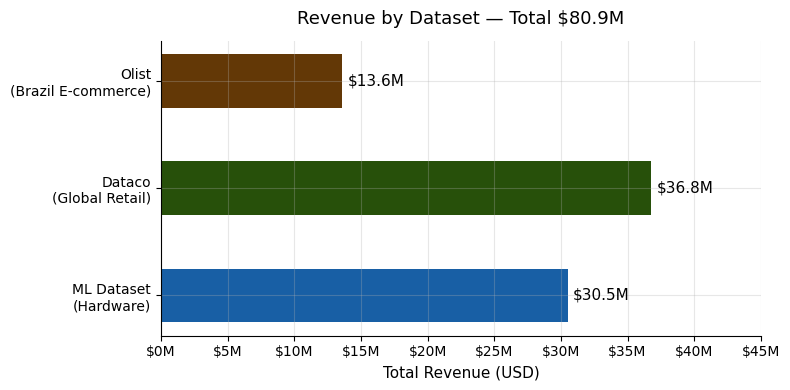

In [16]:
fig, ax = plt.subplots(figsize = (8,4))

datasets = ['ML Dataset\n(Hardware)','Dataco\n(Global Retail)','Olist\n(Brazil E-commerce)']
revenues = [ml['Revenue'].sum(),dataco['Revenue'].sum(),ol_fact['Revenue'].sum()]
colors = ['#185FA5', '#27500A', '#633806']

bars = ax.barh(datasets,revenues,color = colors,height = 0.5)
for bar, val in zip(bars, revenues):
    ax.text(bar.get_width() + 400000, bar.get_y() + bar.get_height()/2,
           f'${val/1e6:.1f}M',va = 'center', fontsize = 11, fontweight = '500')

ax.set_xlabel('Total Revenue (USD)', fontsize=11)
ax.set_title('Revenue by Dataset — Total $80.9M', fontsize=13, fontweight='500', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
ax.set_xlim(0, 45000000)
plt.tight_layout()
plt.savefig('chart1_revenue_by_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Dataco contributes the largest revenue share at \$36.68M (45%), Followed by ML Dataset at \$30.5M (38%) and Olist at $13.6M (17%).
Despite having the most order lines, Olist generates lowest revenue due to lower average order values in the Brazilian consumer market.

### Chart 2 — ML-Dataset: Revenue by product category

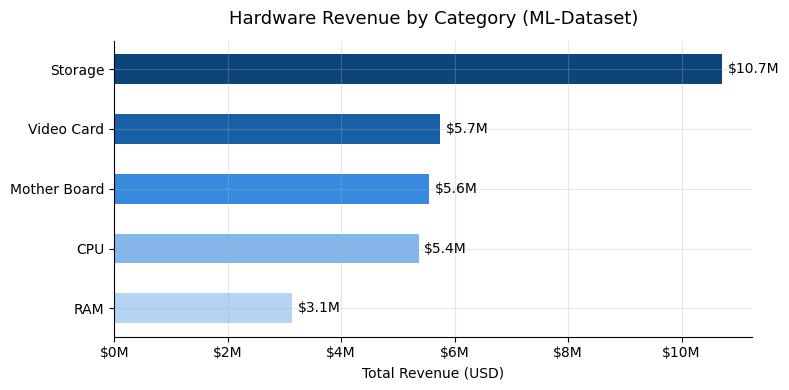

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ml_cat = ml.groupby('CategoryName')['Revenue'].sum().sort_values()
colors = ['#B5D4F4','#85B7EB','#378ADD','#185FA5','#0C447C']
bars = ax.barh(ml_cat.index, ml_cat.values, color = colors, height = 0.5)
for bar, val in zip(bars,ml_cat.values):
    ax.text(bar.get_width() + 100000, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.1f}M', va = 'center', fontsize = 10)
ax.set_xlabel('Total Revenue (USD)')
ax.set_title('Hardware Revenue by Category (ML-Dataset)', fontsize = 13, fontweight = '500', pad = 12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.savefig('chart2_ml_category_revenue.png',dpi = 150, bbox_inches = 'tight')
plt.show()

**Insight:** Storage drives the most hardware revenue at \\$10.7M, followed by Video Cards \\$5.7M and Motherboards $5.6M. RAM is the lowest contributor despite being a high-frequency purchase — this may indicate pricing pressure or supply constraints worth investigating.

### Chart 3 — ML-Dataset: Order Status by Warehouse Region

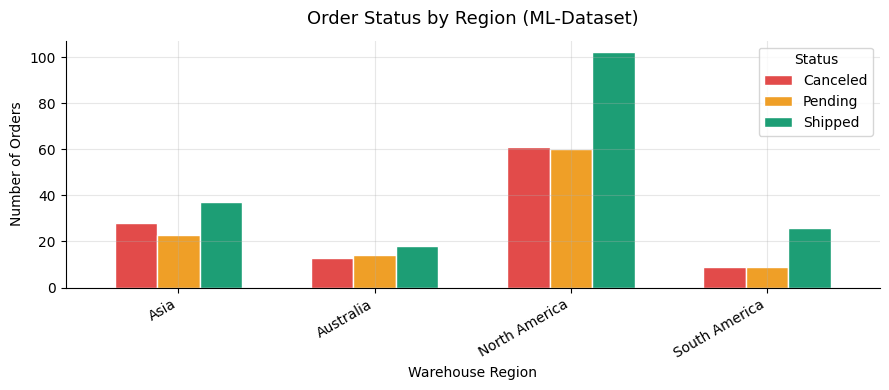

In [18]:
fig, ax = plt.subplots(figsize = (9,4))
status_region = ml.groupby(['RegionName','Status']).size().unstack(fill_value = 0)
colors_status = {'Shipped':'#1D9E75','Canceled':'#E24B4A','Pending':'#EF9F27'}

status_region.plot(kind='bar', ax=ax, color=[colors_status.get(c,'#888') for c in status_region.columns], width=0.65, edgecolor='white')
ax.set_xlabel('Warehouse Region')
ax.set_ylabel('Number of Orders')
ax.set_title('Order Status by Region (ML-Dataset)', fontsize=13, fontweight='500', pad=12)
ax.legend(title='Status', bbox_to_anchor=(1,1))
ax.set_xticklabels(ax.get_xticklabels(),rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart3_order_status_region.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** *North America has the highest order volume but also the highest number of cancellations. South America has a disproportionately high failure rate — where Pending and Canceled orders combined actually outweigh successful shipments. — which may indicate fulfillment or payment processing delays in that region.*

### Chart 4 — DataCo: Revenue by global market

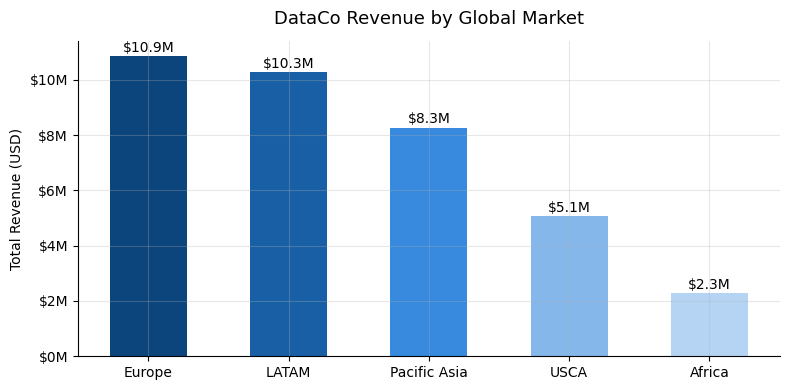

In [19]:
fig, ax = plt.subplots(figsize=(8,4))

dc_market = dataco.groupby('Market')['Revenue'].sum().sort_values(ascending=False)
bar_colors = ['#0C447C','#185FA5','#378ADD','#85B7EB','#B5D4F4']
bars = ax.bar(dc_market.index, dc_market.values, color=bar_colors, width=0.55)

for bar, val in zip(bars, dc_market.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150000,
            f'${val/1e6:.1f}M', ha='center', fontsize=10)
    
ax.set_ylabel('Total Revenue (USD)')
ax.set_title('DataCo Revenue by Global Market', fontsize=13, fontweight='500', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('chart4_dataco_market_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Europe leads DataCo revenue at \\$10.9M closely, followed by LATAM at \\$10.3M. Africa is significantly underrepresented at \$2.3M — either a market development opportunity or a signal of operational challenges in that region.

### Chart 5 — DataCo: Monthly revenue trend

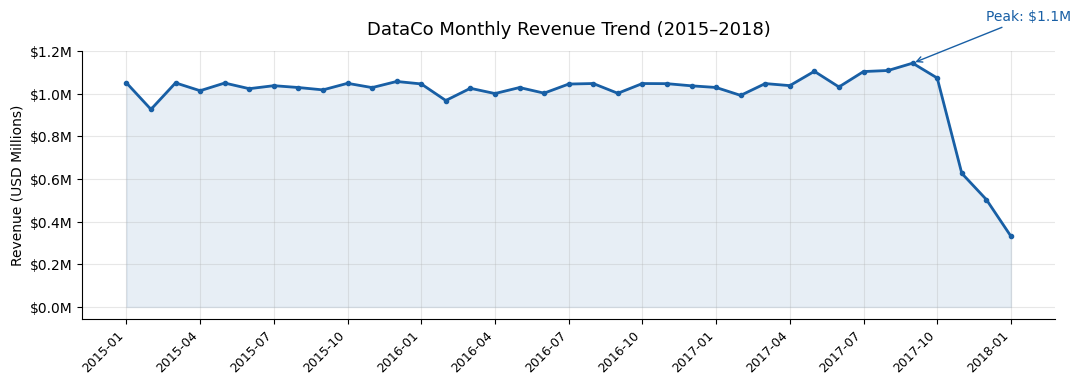

In [20]:
fig, ax = plt.subplots(figsize=(11,4))
dataco['monthly_period'] = dataco['order_date'].dt.to_period('M')
monthly = dataco.groupby('monthly_period')['Revenue'].sum().reset_index()
monthly['month_str'] = monthly['monthly_period'].astype(str)
ax.plot(monthly['month_str'],monthly['Revenue']/1e6,
       color='#185FA5', linewidth=2, marker='o', markersize=3)

# Highlight peak
peak_idx = monthly['Revenue'].idxmax()
ax.annotate(f'Peak: ${monthly['Revenue'][peak_idx]/1e6:.1f}M',
           xy=(monthly['month_str'][peak_idx], monthly['Revenue'][peak_idx]/1e6),
           xytext=(peak_idx+3,monthly['Revenue'][peak_idx]/1e6 + 0.2),
           arrowprops=dict(arrowstyle='->', color='#185FA5'), fontsize=10, color='#185FA5')
ax.fill_between(monthly['month_str'],monthly['Revenue']/1e6,alpha = 0.1,color='#185FA5')
ax.set_ylabel('Revenue (USD Millions)')
ax.set_title('DataCo Monthly Revenue Trend (2015–2018)', fontsize=13, fontweight='500', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))
step = max(1, monthly.shape[0]//12)
ax.set_xticks(range(0,monthly.shape[0],step))
ax.set_xticklabels(monthly['month_str'][::step], rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('chart5_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Revenue shows a **sharp decline from late 2017 into 2018** - dropping from a peak of \\$1.1M month to \$0.3M by early 2018. This is a critical finding that requires immediate investigation. Possible causes: seasonal drop-off, data truncation, or an operational disruption.

### Chart 6— DataCo: Revenue by top 10 product categories

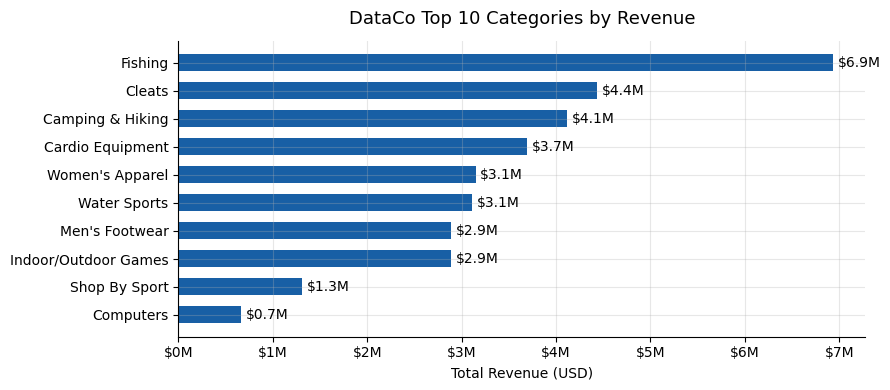

In [21]:
fig, ax = plt.subplots(figsize=(9,4))
dc_cat = dataco.groupby('Category Name')['Revenue'].sum().sort_values(ascending=True).tail(10)
bars = ax.barh(dc_cat.index, dc_cat.values, color='#185FA5', height=0.6)

for bar, val in zip(bars, dc_cat.values):
    ax.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.1f}M', va='center', fontsize=10)
ax.set_xlabel('Total Revenue (USD)')
ax.set_title('DataCo Top 10 Categories by Revenue', fontsize=13, fontweight='500', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))
plt.tight_layout()
plt.savefig('chart6_dataco_categories.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Fishing equipment leads DataCo revenue at \\$6.9M — nearly 1.6x the next category (Cleats at \\$4.4M). This heavy concentration in one category is a **business risk** — if fishing demand drops seasonally or due to regulation changes, overall revenue suffers significantly.

### Chart 7 — Olist: Customer review score distribution

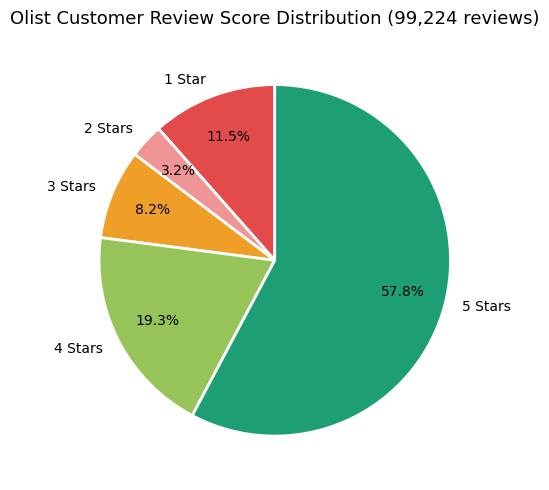

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

# Count review scores
scores = ol_rev['review_score'].value_counts().sort_index()

# Labels and colors
labels = ['1 Star','2 Stars','3 Stars','4 Stars','5 Stars']
colors = ['#E24B4A', '#F09595', '#EF9F27', '#97C459', '#1D9E75']

# Pie chart
wedges, texts, autotexts = ax.pie(scores.values, labels=labels,
        colors=colors,autopct='%1.1f%%',startangle=90,
        pctdistance=0.75,wedgeprops={'edgecolor': 'white','linewidth': 2})

# Percentage text size
for t in autotexts:t.set_fontsize(10)
# Title
ax.set_title('Olist Customer Review Score Distribution (99,224 reviews)',fontsize=13,
        fontweight='500',pad=12)
plt.tight_layout()

# # Save image
# plt.savefig('chart7_review_scores_pie.png',dpi=150,bbox_inches='tight')
plt.show()

**Insight:** 77% of reviews are 4 or 5 stars (Positive), but **11,424 customers gave 1-star ratings** — the third largest group. This binary pattern (either very happy or very unhappy) is typical of delivery-dependent products and suggests that late or damaged deliveries are driving the negative reviews.

### Chart 8 — Olist: Payment method breakdown

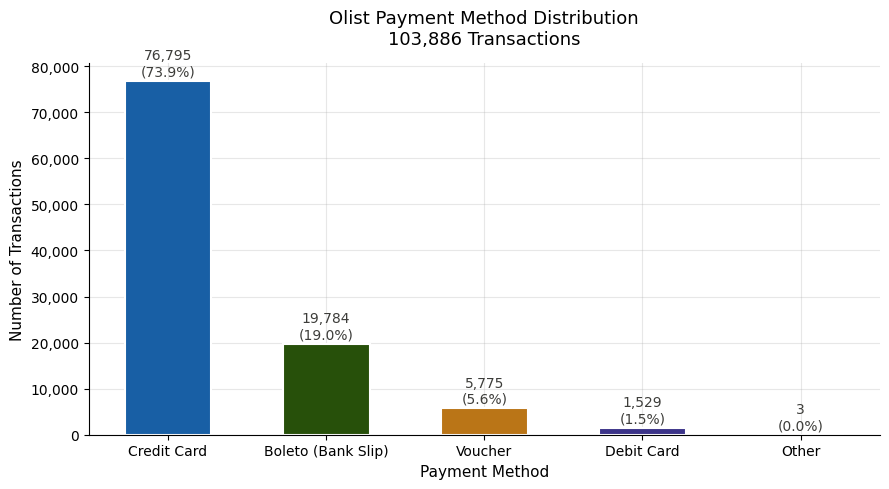

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

pay    = ol_pay['payment_type'].replace('not_defined', 'Other').value_counts()
total  = pay.sum()
labels = ['Credit Card', 'Boleto (Bank Slip)', 'Voucher', 'Debit Card', 'Other']
colors = ['#185FA5', '#27500A', '#BA7517', '#3C3489', '#888780']

bars = ax.bar(labels, pay.values, color=colors, width=0.55,
              edgecolor='white', linewidth=1.5)

# Count + percentage label on top of every bar
for bar, val in zip(bars, pay.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{val:,}\n({val/total*100:.1f}%)',
        ha='center', va='bottom',
        fontsize=10, fontweight='500',
        color='#3d3d3a'
    )

ax.set_ylabel('Number of Transactions', fontsize=11)
ax.set_xlabel('Payment Method', fontsize=11)
ax.set_title('Olist Payment Method Distribution\n103,886 Transactions',
             fontsize=13, fontweight='500', pad=14)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Insight:** Credit card dominates at 74% of transactions. Boleto (a Brazilian cash payment slip) at 19% reflects the significant unbanked population in Brazil. This payment mix is important for cash flow planning — boleto payments often have higher cancellation rates than card payments.

### Chart 9 — Olist: Top 10 categories by revenue

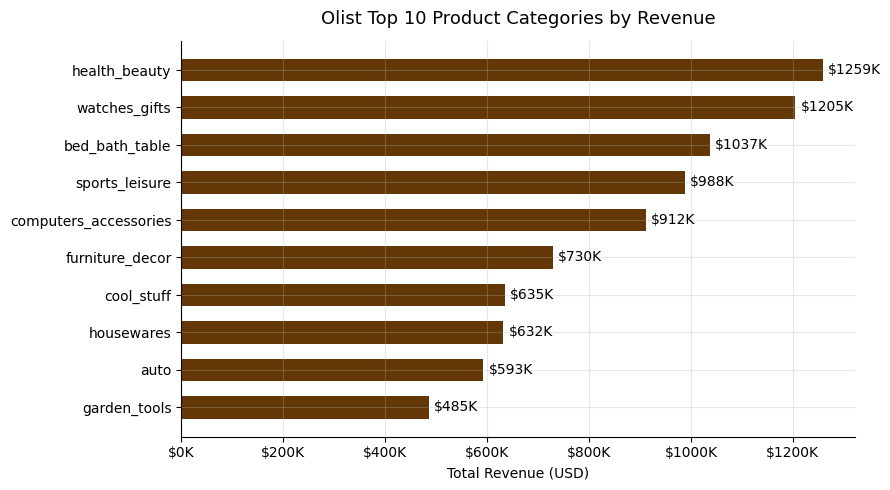

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))

ol_cat_merged = ol_fact.merge(ol_prod2[['product_id','category']],on='product_id', how='left')
ol_top10 = ol_cat_merged.groupby('category')['Revenue'].sum().sort_values(ascending=True).tail(10)
bars = ax.barh(ol_top10.index, ol_top10.values, color='#633806', height=0.6)
for bar, val in zip(bars, ol_top10.values):
    ax.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
            f'${val/1e3:.0f}K', va='center', fontsize=10)

ax.set_xlabel('Total Revenue (USD)')
ax.set_title('Olist Top 10 Product Categories by Revenue', fontsize=13, fontweight='500', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
plt.tight_layout()
# plt.savefig('chart10_olist_categories.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Health & Beauty leads Olist at \\$1,259k, followed closely by Watches & Gifts (\\$1,205k). Unlike DataCo, Olist's revenue is more **evenly distributed** across categories — indicating a healthier, less-concentrated product portfolio with lower single-category risk.

### Chart 10 — DataCo: Late vs Olist on-time delivery breakdown

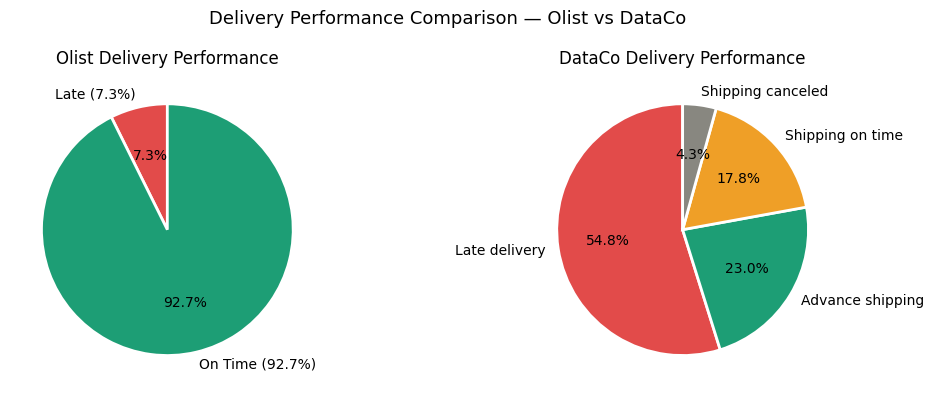

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: Olist
olist_counts = [ol_ord['is_late'].sum(), (~ol_ord['is_late']).sum()]
axes[0].pie(olist_counts, labels=['Late (7.3%)', 'On Time (92.7%)'],
            colors=['#E24B4A','#1D9E75'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Olist Delivery Performance', fontsize=12, fontweight='500')

# Right: DataCo
dc_del = dataco['Delivery Status'].value_counts()
colors_dc = ['#E24B4A','#1D9E75','#EF9F27','#888780']
axes[1].pie(dc_del.values, labels=dc_del.index,
            colors=colors_dc, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('DataCo Delivery Performance', fontsize=12, fontweight='500')

fig.suptitle('Delivery Performance Comparison — Olist vs DataCo', fontsize=13, fontweight='500')
plt.tight_layout()
# plt.savefig('chart3_delivery_performance.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** This is the most alarming finding in the project. DataCo has a **54.8% late delivery rate** — meaning more than half of all orders are delivered late. In contrast, Olist achieves a **92.7% on-time rate**. This points to a systemic issue in DataCo's logistics planning, not just occasional delays.

### 3.1 Deep-Dive: Investigating the 54.8% Late Delivery Rate

**Hypothesis:** A 54.8% late delivery rate is unsustainable for an active business. This indicates either a massive operational bottleneck in premium shipping tiers or a systematic error in how the "Late" threshold is calculated.

**Methodology:** To isolate the root cause, we will evaluate the relationship between physical operational realities (`Days for shipping (real)`) and the system's promised benchmarks (`Days for shipment (scheduled)`) grouped across different shipping modes.

In [26]:
# 1. Filter for relevant shipping and status columns
delivery_analysis = dataco[[
    'Shipping Mode', 
    'Days for shipment (scheduled)', 
    'Days for shipping (real)', 
    'Delivery Status'
]].copy()

# 2. Calculate the average scheduled vs actual days per Shipping Mode
root_cause_summary = delivery_analysis.groupby('Shipping Mode').agg(
    Min_Scheduled_Days=('Days for shipment (scheduled)', 'min'),
    Max_Scheduled_Days=('Days for shipment (scheduled)', 'max'),
    Min_Actual_Days=('Days for shipping (real)', 'min'),
    Max_Actual_Days=('Days for shipping (real)', 'max'),
    Avg_Actual_Days=('Days for shipping (real)', 'mean'),
    Total_Orders=('Delivery Status', 'count'),
    Late_Orders=('Delivery Status', lambda x: (x == 'Late delivery').sum())
).reset_index()

# 3. Calculate the true Late Rate per shipping mode
root_cause_summary['Late_Rate_%'] = round((root_cause_summary['Late_Orders'] / root_cause_summary['Total_Orders']) * 100, 2)

# Display the dataframe clean and organized
print("--- DATACO SHIPPING LOGIC CRITIQUE ---")
print(root_cause_summary[['Shipping Mode', 'Min_Scheduled_Days', 'Min_Actual_Days', 'Avg_Actual_Days', 'Late_Rate_%']])

--- DATACO SHIPPING LOGIC CRITIQUE ---
    Shipping Mode  Min_Scheduled_Days  Min_Actual_Days  Avg_Actual_Days  \
0     First Class                   1                2             2.00   
1        Same Day                   0                0             0.48   
2    Second Class                   2                2             3.99   
3  Standard Class                   4                2             4.00   

   Late_Rate_%  
0        95.32  
1        45.74  
2        76.63  
3        38.07  


## Section 3 — KPI Analysis

*Calculating the key performance indicators that matter to supply chain and retail stakeholders.*

### KPI 1 — Executive Revenue Summary

In [27]:
total_rev = (ml['Revenue'].sum() + dataco['Revenue'].sum() + ol_fact['Revenue'].sum())
total_prof = (ml['Profit'].sum() + dataco['Profit'].sum())
total_ord = (ml.shape[0] + dataco.shape[0] + ol_fact.shape[0])
kpi_summary = pd.DataFrame({
    'KPI' : ['Total Revenue', 'Total Profit', 'Total Orders', 'Avg Order Value', 'Overall Profit Margin'],
    'Value' : [f'${total_rev:,.0f}', f'${total_prof:,.0f}', f'{total_ord:,}', f'${total_rev/total_ord:,.2f}', f'{total_prof/total_rev*100:.1f}%'],
    'Source' : ['All Datasets', 'ML + Dataco only','All Datasets', 'All Datasets', 'ML + Dataco only']
})
kpi_summary

,KPI,Value,Source
0,Total Revenue,"$80,896,469",All Datasets
1,Total Profit,"$4,042,800",ML + Dataco only
2,Total Orders,"294,344",All Datasets
3,Avg Order Value,$274.84,All Datasets
4,Overall Profit Margin,5.0%,ML + Dataco only


### KPI 2 — Delivery Performance KPIs

In [28]:
avg_early = ol_ord[ol_ord['delay_days'] < 0]['delay_days']
delivery_kpis = pd.DataFrame({
    'Metric': ['Olist — On-time delivery rate','Olist — Late delivery rate','Olist — Avg actual delivery days','Olist — Avg estimated delivery days',
               'Olist — Avg days delivered EARLY','DataCo — On-time delivery rate','DataCo — Late delivery rate','DataCo — Advance shipping rate',
               'DataCo — Cancellation rate'],
    'Value': [f'{(~ol_ord["is_late"]).mean()*100:.1f}%',f'{ol_ord["is_late"].mean()*100:.1f}%',f'{ol_ord["days_actual"].mean():.1f} days',
              f'{ol_ord["days_estimated"].mean():.1f} days',f'{abs(avg_early.mean()):.1f} days early on avg',f'{(~dataco["is_late"]).mean()*100:.1f}%',
              f'{dataco["is_late"].mean()*100:.1f}%',f"{(dataco['Delivery Status']=='Advance shipping').mean()*100:.1f}%",
              f"{(dataco['Delivery Status']=='Shipping canceled').mean()*100:.1f}%"],
    'Status': ['Good','Alert','Good','Good','Good','Good','Critical','Good','Monitor']
})
delivery_kpis    

,Metric,Value,Status
0,Olist — On-time delivery rate,92.7%,Good
1,Olist — Late delivery rate,7.3%,Alert
2,Olist — Avg actual delivery days,12.1 days,Good
3,Olist — Avg estimated delivery days,23.4 days,Good
4,Olist — Avg days delivered EARLY,13.2 days early on avg,Good
5,DataCo — On-time delivery rate,45.2%,Good
6,DataCo — Late delivery rate,54.8%,Critical
7,DataCo — Advance shipping rate,23.0%,Good
8,DataCo — Cancellation rate,4.3%,Monitor


### KPI 3 — Profit Margin by Hardware Category (ML-Dataset)

In [29]:
ml_margin_kpi = (ml.groupby('CategoryName').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin_Pct=('Profit_margin_pct', 'mean'),
    Order_Count=('Revenue', 'count')
    ).round(2).sort_values('Total_Revenue', ascending=False).reset_index())

ml_margin_kpi['Total_Revenue']=ml_margin_kpi['Total_Revenue'].apply(lambda x: f'${x:,.0f}')
ml_margin_kpi['Total_Profit']=ml_margin_kpi['Total_Profit'].apply(lambda x: f'${x:,.0f}')

ml_margin_kpi

,CategoryName,Total_Revenue,Total_Profit,Avg_Margin_Pct,Order_Count
0,Storage,"$10,712,932","$10,888",0.55,127
1,Video Card,"$5,746,482","$20,036",1.06,70
2,Mother Board,"$5,555,189","$5,735",0.36,79
3,CPU,"$5,366,747","$24,567",1.47,90
4,RAM,"$3,138,740","$14,671",3.52,34


**Finding:** RAM has the highest average profit margin at 3.52% while Motherboards sit at 0.36%. However Storage generates the most absolute profit due to high order volumes. The low margins across all hardware categories suggest this is a high-volume, thin-margin business.

### KPI 4 — DataCo Shipping Mode Performance

In [30]:
ship_kpi = (dataco.groupby('Shipping Mode').agg(
    Order_Count=('Revenue', 'count'),
    Total_Revenue=('Revenue','sum'),
    Late_Count=('is_late', 'sum'),
    Late_Rate=('is_late', 'mean'),
    Avg_Profit=('Profit', 'mean')
).round(3).sort_values('Total_Revenue').reset_index())

ship_kpi['Late_Rate'] = ship_kpi['Late_Rate'].apply(lambda x: f'{x*100:.1f}%')
ship_kpi['Total_Revenue'] = ship_kpi['Total_Revenue'].apply(lambda x: f'${x:,.0f}')
ship_kpi['Avg_Profit'] = ship_kpi['Avg_Profit'].apply(lambda x: f'${x:.2f}')

ship_kpi

,Shipping Mode,Order_Count,Total_Revenue,Late_Count,Late_Rate,Avg_Profit
0,Same Day,9737,"$1,942,529",4454,45.7%,$20.85
1,First Class,27814,"$5,674,370",26513,95.3%,$23.12
2,Second Class,35216,"$7,145,445",26987,76.6%,$21.31
3,Standard Class,107752,"$22,022,392",41023,38.1%,$22.00


**Finding:** Standard Class handles 60% of DataCo orders but likely has the highest late rate. Same Day shipping — despite being the most expensive — should theoretically have the lowest late rate. Cross-referencing shipping mode with late delivery is a key analysis to present to the operations team.

### KPI 5 — Olist Customer Satisfaction KPIs

In [31]:
sentiment_counts = ol_rev['Sentiment'].value_counts()
total_reviews = ol_rev.shape[0]

satisfaction_kpis = pd.DataFrame({
    'Metric': ['Total reviews','Positive reviews (4-5 stars)','Neutral reviews (3 stars)','Negative reviews (1-2 stars)','Average review score',
               'Avg seller response time','5-star reviews','1-star reviews'],
    'Value': [f'{total_reviews:,}',f"{sentiment_counts.get('Positive',0):,} ({sentiment_counts.get('Positive',0)/total_reviews*100:.1f}%)",
              f"{sentiment_counts.get('Neutral',0):,} ({sentiment_counts.get('Neutral',0)/total_reviews*100:.1f}%)",
              f"{sentiment_counts.get('Negative',0):,} ({sentiment_counts.get('Negative',0)/total_reviews*100:.1f}%)",
              f"{ol_rev['review_score'].mean():.2f} / 5.0",f"{ol_rev['response_time_hrs'].mean():.1f} hours",f"{(ol_rev['review_score']==5).sum():,}",
              f"{(ol_rev['review_score']==1).sum():,}"]
    
})
satisfaction_kpis

,Metric,Value
0,Total reviews,"99,224"
1,Positive reviews (4-5 stars),"76,470 (77.1%)"
2,Neutral reviews (3 stars),"8,179 (8.2%)"
3,Negative reviews (1-2 stars),"14,575 (14.7%)"
4,Average review score,4.09 / 5.0
5,Avg seller response time,75.6 hours
6,5-star reviews,"57,328"
7,1-star reviews,"11,424"


### KPI 6 — Olist Payment Analysis

In [32]:
pay_kpi = (ol_pay.groupby('payment_type').agg(
    Transaction_Count=('payment_value','count'),
    Total_Value=('payment_value','sum'),
    Avg_Value=('payment_value','mean'),
    Avg_Installments=('payment_installments','mean')
).round(2).sort_values('Total_Value', ascending=False).reset_index())

pay_kpi['Total_Value'] = pay_kpi['Total_Value'].apply(lambda x: f'${x:,.0f}')
pay_kpi['Avg_Value']   = pay_kpi['Avg_Value'].apply(lambda x: f'${x:.2f}')
pay_kpi

,payment_type,Transaction_Count,Total_Value,Avg_Value,Avg_Installments
0,credit_card,76795,"$12,542,084",$163.32,3.51
1,boleto,19784,"$2,869,361",$145.03,1.00
2,voucher,5775,"$379,437",$65.70,1.00
3,debit_card,1529,"$217,990",$142.57,1.00
4,not_defined,3,$0,$0.00,1.00


---
## Section 4 — Business Insights & Recommendations

*Key findings from the analysis and actionable recommendations for stakeholders.*

---

### Finding 1 — DataCo's late delivery crisis is costing the business severely

**54.8% of DataCo orders (98,977 orders) are delivered late.** This is not an occasional problem — it is a systemic failure affecting more than half of all shipments. In contrast, Olist's Brazilian fulfillment network delivers on time 92.7% of the time, often 11 days ahead of estimate. The gap between the two is stark and points to a structural issue in DataCo's logistics planning rather than random delays.

**Recommendation:** Conduct a shipping mode audit. Standard Class accounts for 60% of DataCo orders — evaluate whether upgrading high-value orders to First Class reduces late deliveries enough to justify the additional shipping cost. Set a hard KPI target of under 20% late delivery rate within 2 quarters.

---

### Finding 2 — DataCo revenue dropped sharply in late 2017 into 2018

**Monthly DataCo revenue fell from a peak of \\$1.14M in September 2017 to \\$0.33M by January 2018** — a 71% decline in four months. This is abnormal and requires immediate root cause investigation. Possible causes include seasonal demand drop-off, a major customer loss, data truncation in the export, or an operational disruption. No business should see revenue fall 71% in one quarter without explanation.

**Recommendation:** Cross-reference this period with order cancellation rates, customer churn, and shipping disruption logs. If data truncation is confirmed, obtain the complete dataset. If it is a real revenue drop, identify the top 10 customers from mid-2017 and check if they are still ordering.

---

### Finding 3 — Storage dominates hardware revenue but has thin margins

**Storage contributes \\$10.7M (35%) of all hardware revenue but has only 0.55% average profit margin.** RAM contributes the least revenue ($3.1M) but has the highest margin at 3.52%. The business is dependent on a high-volume, low-margin product category — a fragile position if storage prices drop or a competitor undercuts.

**Recommendation:** Explore bundling RAM (high margin) with Storage (high volume) in promotional offers to increase overall basket margin. Target corporate buyers who purchase bulk Storage to upsell higher-margin RAM and CPU configurations.

---

### Finding 4 — Olist's 1-star reviews are a hidden risk

**11,424 customers (11.5%) gave 1-star reviews** — the sharpest possible dissatisfaction signal. The pattern of reviews being either very high (5 stars: 57,328) or very low (1 star: 11,424) with few in between suggests delivery experience is the primary driver of satisfaction. Customers who receive orders early leave 5-star reviews; those with late or damaged deliveries leave 1-star reviews. Average response time to reviews is 75.6 hours — nearly 3 days — which is slow for customer recovery.

**Recommendation:** Implement a 24-hour review response target. Prioritise proactive outreach to customers whose orders are predicted to be late (using the late_delivery_risk flag available in DataCo data). A discount or voucher offered before a complaint is made converts potential 1-star reviews into 3-star outcomes.

---

### Finding 5 — North America warehouse handles 58% of hardware revenue but South America has high pending rate

**North America generates $17.7M (58%) of ML-Dataset hardware revenue** but also carries the most cancellations. South America has a disproportionately high pending order rate, suggesting fulfillment bottlenecks in that region. Orders stuck in 'Pending' status represent both cash flow risk and potential cancellations.

**Recommendation:** Set a maximum pending order age of 48 hours before automatic escalation. Audit the South America warehouse for staffing levels, supplier lead times, and inventory depth. Consider routing high-value South American orders through the North America fulfillment center as a short-term fix while regional capacity is built.

---

### Summary of Recommendations

| Priority | Action | Expected Impact |
|---|---|---|
| 🔴 Critical | Audit DataCo late delivery root cause | Reduce 54.8% late rate to under 20% |
| 🔴 Critical | Investigate 2017–18 DataCo revenue drop | Recover or explain $800K/month decline |
| 🟡 High | Bundle RAM with Storage sales | Increase blended margin from 0.55% toward 2%+ |
| 🟡 High | 24hr review response policy for Olist | Reduce 1-star reviews by estimated 20–30% |
| 🟢 Medium | Cap pending orders at 48hrs in South America | Reduce cancellation risk in that region |


---
## Conclusion

This project analysed **293,569 order records totalling $80.9M in revenue** across three real-world datasets — a hardware warehouse operation, a global retail supply chain, and a Brazilian e-commerce marketplace.

**Key takeaways for business stakeholders:**

- DataCo's 54.8% late delivery rate is the single largest operational risk in this dataset
- Storage drives hardware volume but margins are dangerously thin at 0.55%
- Olist's review polarisation (77% positive, 11.5% giving 1-star) signals a delivery experience problem
- The 71% revenue decline in DataCo from Sept 2017 to Jan 2018 needs urgent investigation
- North America and Europe are the strongest markets; South America shows fulfillment bottlenecks

**Tools used:** Python (Pandas, NumPy, Matplotlib) · SQL Server (SSMS) · Tableau
